In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(accuracy_score,classification_report,confusion_matrix)

In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "axes.titlesize":10,
    "axes.labelsize":9,
    "xtick.labelsize":8,
    "ytick.labelsize":8
})
Random_state=42
csv_path="WELFake_Dataset.csv"
target="label"

In [3]:
data=pd.read_csv(csv_path)

In [4]:
data.shape

(72134, 4)

In [5]:
data.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [6]:
data.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='str')

In [7]:
data=data.drop(columns="Unnamed: 0")

In [8]:
print(data["label"].value_counts())

label
1    37106
0    35028
Name: count, dtype: int64


In [9]:
print(data["label"].value_counts(normalize=True))

label
1   0.514
0   0.486
Name: proportion, dtype: float64


In [10]:
df_fake=data[data["label"]==0]
df_real=data[data["label"]==1]
df_fake_sample=df_fake.sample(10000,random_state=Random_state)
df_real_sample=df_real.sample(10000,random_state=Random_state)
df=(
    pd.concat([df_fake_sample,df_real_sample]).sample(frac=1,random_state=Random_state)
.reset_index(drop=True))
# choosing a sample instead of whole data inorder to reduce complexity


In [11]:
df.columns

Index(['title', 'text', 'label'], dtype='str')

In [12]:
df["label"].value_counts()

label
1    10000
0    10000
Name: count, dtype: int64

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   19867 non-null  str  
 1   text    19989 non-null  str  
 2   label   20000 non-null  int64
dtypes: int64(1), str(2)
memory usage: 468.9 KB


In [14]:
df.isnull().sum()

title    133
text      11
label      0
dtype: int64

In [15]:
df=df.dropna()

In [16]:
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [17]:
df["label"].value_counts(normalize=True)

label
0   0.504
1   0.496
Name: proportion, dtype: float64

In [18]:
df["label"]

0        1
1        0
2        0
3        0
4        1
        ..
19994    0
19995    1
19996    1
19997    0
19998    0
Name: label, Length: 19856, dtype: int64

In [19]:
#clean the text
def clean_text(s: str) -> str:
    if pd.isna(s):
        return ""
    s=str(s).lower()
    s=re.sub(r"http\S+|www\.\S+"," ",s) #urls 
    s=re.sub(r"<.*?>"," ",s)            #html tags
    s=re.sub(r"[^a-z0-9\s\.\,\!\?\-\']"," ",s) #keep basic chars
    s=re.sub(r"\s+"," ",s).strip()
    return s


In [20]:
#combine title and text 
#  for nlp its bettter to work on one column
df["content"]=(df["title"]+" "+df["text"]).apply(clean_text)

In [21]:
df.head()

,title,text,label,content
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1,breaking obama s war on cops another cop ambus...
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0,pennsylvania bans bias against transgender peo...
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0,u.s. lawmakers aim to comply with iran nuclear...
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0,more than 60 killed in air strike on syrian ma...
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1,virginia republican says conservatives own chr...


In [22]:
#adding additional columns for analysis
df["title_len"]=df["title"].str.len()
df["text_len"]=df["text"].str.len()
df["content_len"]=df["content"].str.len()


In [23]:
df.head()

,title,text,label,content,title_len,text_len,content_len
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1,breaking obama s war on cops another cop ambus...,134,5854,5970
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0,pennsylvania bans bias against transgender peo...,49,751,796
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0,u.s. lawmakers aim to comply with iran nuclear...,55,2736,2771
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0,more than 60 killed in air strike on syrian ma...,55,1775,1815
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1,virginia republican says conservatives own chr...,100,3451,3545


In [24]:
num_cols=["title_len","text_len","content_len"]
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
title_len,19856.000,76.993,25.072,4.000,62.000,73.000,89.000,286.000
text_len,19856.000,3283.625,3658.956,1.000,1414.750,2435.000,4081.500,115372.000
content_len,19856.000,3312.367,3616.117,0.000,1455.000,2477.000,4111.250,114506.000


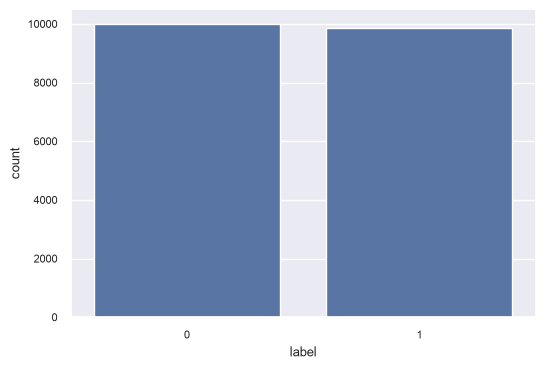

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="label",data=df)
plt.show()

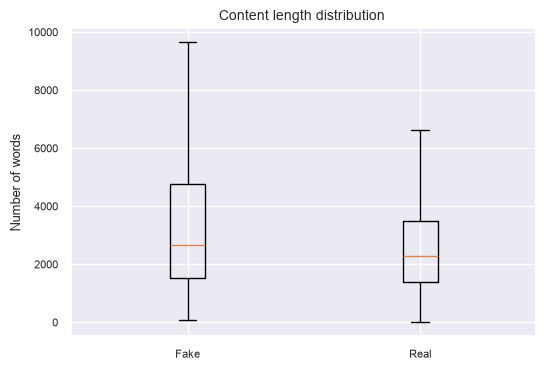

In [ ]:
fake_lens=df[df["label"]==0]["content_len"].values
real_lens=df[df["label"]==1]["content_len"].values
plt.figure(figsize=(6,4))
plt.boxplot(
    
        [fake_lens,real_lens],
        tick_labels=["Fake","Real"],
        showfliers=False
)
plt.title("Content length distribution ")
plt.ylabel("Number of words")
plt.show()
# orange line represents median

In [27]:
print(fake_lens)
print(real_lens)

[ 796 2771 1815 ...  644 2670 5009]
[5970 3545 1345 ... 2732  912 3452]


In [32]:
#seperate features and target
X=df["content"]
y=df["label"]
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,
    stratify=y,
    random_state=Random_state
)

In [33]:
print("Train size:",X_train.shape)

Train size: (15884,)


Vectorization

In [ ]:
#TF-IDF : text to numerical
#term frequency -Inverse document frequency
#common words -> low tf-idf score
#rare ut meaningful words ->high td-idf words


In [34]:
model_pipeline=Pipeline(
    steps=[
        ("tfidf",TfidfVectorizer(
            max_features=50000,
            ngram_range=(1,2), # ex:choose machine ,machine learning
            stop_words="english", # no of phrases to be selected (ngram_range)
            min_df=2
        )),
        ("model",LogisticRegression())
    ]
)

In [ ]:
#already data is normalized dont apply standardscaler

In [35]:
#train the pipeline
model_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",50000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence ite

Model Evaluation

In [ ]:
y_train_pred=model_pipeline.predict(X_train)
y_proba_train=model_pipeline.predict_proba(X_train)[:,1]
acc_train=accuracy_score(y_train,y_train_pred)
cm_train=confusion_matrix(y_train,y_train_pred)
print("\n----Train Metrics----")
print(f"Accuracy :{acc_train:.4f}")
print("\nConfusion Matrix [ [TN FP], [FN,TP] ]:")
print(cm_train)
print("\nClassification Report:")
print(classification_report(y_train,y_train_pred,digits=4))


----Train Metrics----
Accuracy :0.9598

Confusion Matrix [ [TN FP], [FN,TP] ]:
[[7639  361]
 [ 278 7606]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9649    0.9549    0.9599      8000
           1     0.9547    0.9647    0.9597      7884

    accuracy                         0.9598     15884
   macro avg     0.9598    0.9598    0.9598     15884
weighted avg     0.9598    0.9598    0.9598     15884



In [38]:
y_test_pred=model_pipeline.predict(X_test)
y_proba_train=model_pipeline.predict_proba(X_test)[:,1]
acc_train=accuracy_score(y_test,y_test_pred)
cm_train=confusion_matrix(y_test,y_test_pred)
print("\n----Test Metrics----")
print(f"Accuracy :{acc_train:.4f}")
print("\nConfusion Matrix [ [TN FP], [FN,TP] ]:")
print(cm_train)
print("\nClassification Report:")
print(classification_report(y_test,y_test_pred,digits=4))


----Test Metrics----
Accuracy :0.9348

Confusion Matrix [ [TN FP], [FN,TP] ]:
[[1862  138]
 [ 121 1851]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9390    0.9310    0.9350      2000
           1     0.9306    0.9386    0.9346      1972

    accuracy                         0.9348      3972
   macro avg     0.9348    0.9348    0.9348      3972
weighted avg     0.9348    0.9348    0.9348      3972



In [39]:
def predict_news(title,text):
    combined=clean_text(f"{title} {text}")
    prediction=model_pipeline.predict([combined])
    print(prediction)
    if prediction[0]==1:
        print("This is a Real News")
    else:
        print("This is a Fake news")
        

In [42]:
example1="Breaking :Government announces new economic policy"
exampletext="The finance minister has introduced a new policy today after discussions in parliament........."
prediction=predict_news(example1,exampletext)

[1]
This is a Real News


### Export Model Artifacts for Deployment


In [ ]:
import joblib

# Export end-to-end NLP pipeline (TF-IDF + Classifier)
joblib.dump(model_pipeline, 'model_pipeline.joblib')
print("Pipeline successfully saved to model_pipeline.joblib")
